# 1. Environment Setup and Data Exploration

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Initial Inspection

In [47]:
# Initial Inspection
print("--- Data Information ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Statistical Summary ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#2. Data Cleaning

In [48]:
# Phase 2: Data Cleaning

# 1. Dropping: Remove 'Cabin' due to >70% missing data
df = df.drop('Cabin', axis=1)
print("Dropped 'Cabin' column.")

# 2. Imputation: Fill 'Age' with median
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"Imputed 'Age' with median: {median_age}")

# 3. Imputation: Fill 'Embarked' with mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"Imputed 'Embarked' with mode: {mode_embarked}")

# Verify cleaning results
print('\nMissing values count:')
print(df.isnull().sum())
display(df.head())

Dropped 'Cabin' column.
Imputed 'Age' with median: 28.0
Imputed 'Embarked' with mode: S

Missing values count:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


#3. Feature Engineering (Encoding and Scaling)

In [50]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Label Encoding for 'Sex' (Binary classification)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
print("Label Encoding applied to 'Sex'.")

# 2. One-Hot Encoding for 'Embarked' (Nominal data)
# Use drop_first=True to avoid the dummy variable trap
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
print("One-Hot Encoding applied to 'Embarked'.")

# 3. Standardization (Scaling) for 'Age' and 'Fare'
scaler = StandardScaler()
numerical_to_scale = ['Age', 'Fare']
df[numerical_to_scale] = scaler.fit_transform(df[numerical_to_scale])
print("Standardization applied to 'Age' and 'Fare'.")

# 4. Final cleanup of non-predictive columns
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, errors='ignore')

print('\nFeature Engineering Complete. Prepared Data:')
display(df.head())

Label Encoding applied to 'Sex'.
One-Hot Encoding applied to 'Embarked'.
Standardization applied to 'Age' and 'Fare'.

Feature Engineering Complete. Prepared Data:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,-0.565736,1,0,-0.502445,False,True
1,1,1,0,0.663861,1,0,0.786845,False,False
2,1,3,0,-0.258337,0,0,-0.488854,False,True
3,1,1,0,0.433312,1,0,0.420730,False,True
4,0,3,1,0.433312,0,0,-0.486337,False,True


#4. Outlier Detection and Removal

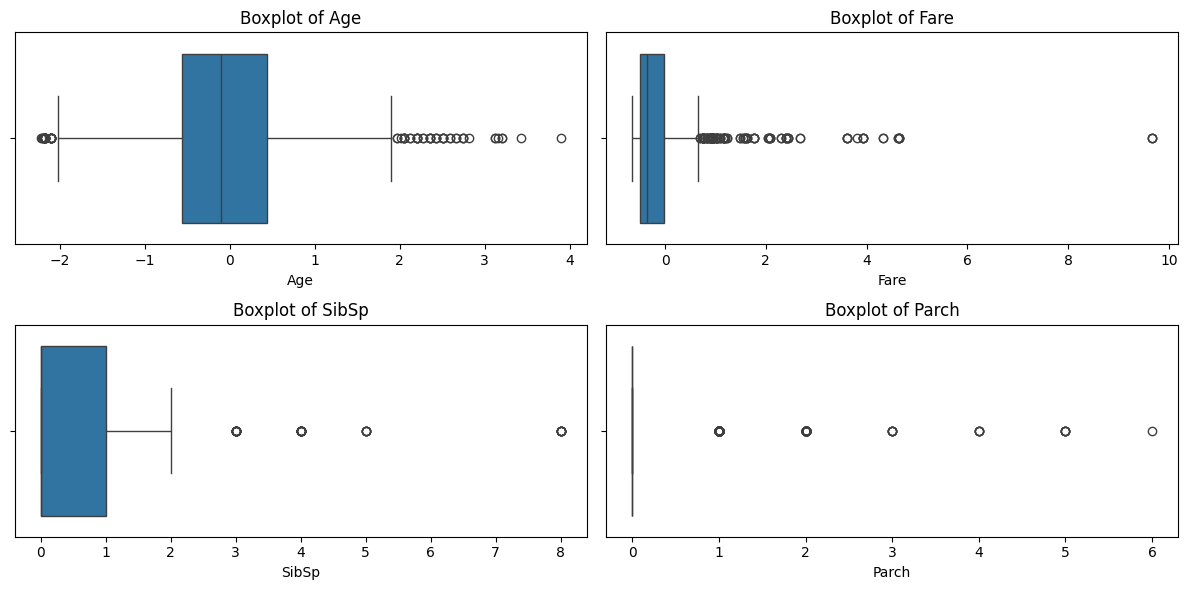

Outliers removed. Dataset shape changed from (891, 9) to (577, 9).


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,-0.565736,1,0,-0.502445,False,True
2,1,3,0,-0.258337,0,0,-0.488854,False,True
3,1,1,0,0.433312,1,0,0.420730,False,True
4,0,3,1,0.433312,0,0,-0.486337,False,True
5,0,3,1,-0.104637,0,0,-0.478116,True,False


In [51]:
# Phase 4: Outlier Detection and Removal
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualization with Boxplots
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']
plt.figure(figsize=(12, 6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# 2. IQR Method for Removal
initial_shape = df.shape
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

final_shape = df.shape
print(f'Outliers removed. Dataset shape changed from {initial_shape} to {final_shape}.')
display(df.head())